In [1]:
!pip -q install xgboost imbalanced-learn joblib

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
import joblib

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [3]:
N = 120_000

class_distribution = {
    "BENIGN": int(N * 0.82),
    "DoS": int(N * 0.18 * 0.35),
    "PortScan": int(N * 0.18 * 0.25),
    "BruteForce": int(N * 0.18 * 0.18),
    "Bot": int(N * 0.18 * 0.12),
}
class_distribution["WebAttack"] = N - sum(class_distribution.values())

feature_names = [
    "flow_duration", "total_fwd_packets", "total_bwd_packets",
    "total_length_fwd_packets", "total_length_bwd_packets",
    "fwd_packet_length_mean", "bwd_packet_length_mean",
    "flow_bytes_per_sec", "flow_packets_per_sec",
    "fwd_iat_mean", "bwd_iat_mean",
    "fwd_psh_flags", "bwd_psh_flags", "fwd_urg_flags", "bwd_urg_flags",
    "syn_flag_count", "fin_flag_count", "rst_flag_count", "ack_flag_count",
    "packet_length_mean", "average_packet_size"
]

profiles = {
    "BENIGN":     {"flow_duration": (50000, 12000), "packets": (18, 5),   "bytes": (8000, 2000),   "rate": (1500, 300),  "flags": (1, 0.5)},
    "DoS":        {"flow_duration": (8000, 2500),   "packets": (120, 25), "bytes": (70000, 15000), "rate": (9500, 1200), "flags": (8, 2)},
    "PortScan":   {"flow_duration": (3000, 1000),   "packets": (6, 2),    "bytes": (1200, 350),    "rate": (4500, 600),  "flags": (15, 3)},
    "BruteForce": {"flow_duration": (18000, 4500),  "packets": (45, 10),  "bytes": (15000, 3500),  "rate": (3500, 600),  "flags": (5, 1.5)},
    "Bot":        {"flow_duration": (65000, 15000), "packets": (35, 8),   "bytes": (10000, 2500),  "rate": (900, 180),   "flags": (3, 1)},
    "WebAttack":  {"flow_duration": (25000, 6000),  "packets": (55, 12),  "bytes": (22000, 5000),  "rate": (3000, 500),  "flags": (7, 2)},
}

def positive_normal(mean, std, size):
    return np.maximum(np.random.normal(mean, std, size), 0.001)

rows = []
for label, count in class_distribution.items():
    p = profiles[label]
    flow_duration = positive_normal(*p["flow_duration"], count)
    total_fwd_packets = np.maximum(np.round(positive_normal(p["packets"][0], p["packets"][1], count)), 1)
    total_bwd_packets = np.maximum(np.round(positive_normal(p["packets"][0] * 0.75, p["packets"][1], count)), 1)
    total_length_fwd = positive_normal(*p["bytes"], count)
    total_length_bwd = positive_normal(p["bytes"][0] * 0.65, p["bytes"][1], count)
    fwd_packet_length_mean = total_length_fwd / total_fwd_packets
    bwd_packet_length_mean = total_length_bwd / total_bwd_packets
    flow_bytes_per_sec = positive_normal(*p["rate"], count)
    flow_packets_per_sec = flow_bytes_per_sec / np.maximum((fwd_packet_length_mean + bwd_packet_length_mean) / 2, 1)
    fwd_iat_mean = flow_duration / total_fwd_packets
    bwd_iat_mean = flow_duration / total_bwd_packets
    syn_flag_count = np.maximum(np.round(positive_normal(p["flags"][0], p["flags"][1], count)), 0)
    fin_flag_count = np.maximum(np.round(positive_normal(p["flags"][0] * 0.25, p["flags"][1], count)), 0)
    rst_flag_count = np.maximum(np.round(positive_normal(p["flags"][0] * 0.35, p["flags"][1], count)), 0)
    ack_flag_count = np.maximum(np.round(positive_normal(p["flags"][0] * 1.5, p["flags"][1], count)), 0)
    fwd_psh_flags = np.maximum(np.round(positive_normal(p["flags"][0] * 0.4, p["flags"][1], count)), 0)
    bwd_psh_flags = np.maximum(np.round(positive_normal(p["flags"][0] * 0.2, p["flags"][1], count)), 0)
    fwd_urg_flags = np.maximum(np.round(positive_normal(p["flags"][0] * 0.1, p["flags"][1] / 2, count)), 0)
    bwd_urg_flags = np.maximum(np.round(positive_normal(p["flags"][0] * 0.08, p["flags"][1] / 2, count)), 0)
    packet_length_mean = (total_length_fwd + total_length_bwd) / (total_fwd_packets + total_bwd_packets)
    average_packet_size = packet_length_mean + np.random.normal(0, 5, count)
    data = np.column_stack([flow_duration,total_fwd_packets,total_bwd_packets,total_length_fwd,total_length_bwd,fwd_packet_length_mean,bwd_packet_length_mean,flow_bytes_per_sec,flow_packets_per_sec,fwd_iat_mean,bwd_iat_mean,fwd_psh_flags,bwd_psh_flags,fwd_urg_flags,bwd_urg_flags,syn_flag_count,fin_flag_count,rst_flag_count,ack_flag_count,packet_length_mean,average_packet_size])
    temp = pd.DataFrame(data, columns=feature_names)
    temp["label"] = label
    rows.append(temp)

df = pd.concat(rows, ignore_index=True).sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (120000, 22)


,flow_duration,total_fwd_packets,total_bwd_packets,total_length_fwd_packets,total_length_bwd_packets,fwd_packet_length_mean,bwd_packet_length_mean,flow_bytes_per_sec,flow_packets_per_sec,fwd_iat_mean,...,bwd_psh_flags,fwd_urg_flags,bwd_urg_flags,syn_flag_count,fin_flag_count,rst_flag_count,ack_flag_count,packet_length_mean,average_packet_size,label
0,32440.481844,15.0,17.0,7447.101485,6702.350693,496.473432,394.255923,1598.248752,3.588629,2162.698790,...,0.0,0.0,0.0,1.0,0.0,0.0,2.0,442.170381,444.029900,BENIGN
1,55970.650718,20.0,11.0,7956.536568,2780.910413,397.826828,252.810038,1200.583593,3.690487,2798.532536,...,0.0,0.0,0.0,1.0,0.0,1.0,2.0,346.369257,351.265363,BENIGN
2,61075.277518,15.0,16.0,9578.015188,5029.767961,638.534346,314.360498,2334.464033,4.899731,4071.685168,...,1.0,0.0,0.0,0.0,1.0,1.0,2.0,471.218811,475.114956,BENIGN
3,63022.667164,27.0,20.0,8742.077612,5322.548569,323.780652,266.127428,1503.742754,5.098227,2334.172858,...,1.0,0.0,0.0,1.0,0.0,0.0,2.0,299.247366,300.236854,BENIGN
4,50842.373498,11.0,17.0,11412.456167,7499.278295,1037.496015,441.134017,1631.505173,2.206779,4622.033954,...,1.0,0.0,0.0,1.0,0.0,0.0,1.0,675.419088,673.723637,BENIGN


In [4]:
print(df["label"].value_counts())
print((df["label"].value_counts(normalize=True) * 100).round(2))
df.to_csv("synthetic_network_intrusion_120k.csv", index=False)

label
BENIGN        98400
DoS            7559
PortScan       5400
BruteForce     3888
Bot            2592
WebAttack      2161
Name: count, dtype: int64
label
BENIGN        82.00
DoS            6.30
PortScan       4.50
BruteForce     3.24
Bot            2.16
WebAttack      1.80
Name: proportion, dtype: float64


In [5]:
X = df[feature_names]
y = df["label"]

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("Label mapping:")
for idx, label in enumerate(label_encoder.classes_):
    print(idx, "->", label)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.20, random_state=RANDOM_STATE, stratify=y_encoded
)

smote = SMOTE(random_state=RANDOM_STATE)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
print("Before SMOTE:", X_train.shape)
print("After SMOTE:", X_train_smote.shape)

Label mapping:
0 -> BENIGN
1 -> Bot
2 -> BruteForce
3 -> DoS
4 -> PortScan
5 -> WebAttack
Before SMOTE: (96000, 21)
After SMOTE: (472320, 21)


In [6]:
models = {
    "Logistic Regression": Pipeline([("scaler", StandardScaler()), ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, n_jobs=-1))]),
    "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=120, random_state=RANDOM_STATE, n_jobs=-1, class_weight="balanced"),
    "XGBoost": XGBClassifier(n_estimators=160, max_depth=7, learning_rate=0.08, subsample=0.9, colsample_bytree=0.9, objective="multi:softprob", eval_metric="mlogloss", random_state=RANDOM_STATE, n_jobs=-1)
}

results = []
for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train_smote, y_train_smote)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    f1 = f1_score(y_test, preds, average="weighted")
    results.append({"Model": name, "Accuracy": acc, "Weighted F1": f1})
    print(f"{name}: Accuracy={acc:.4f}, Weighted F1={f1:.4f}")

results_df = pd.DataFrame(results).sort_values(by="Weighted F1", ascending=False)
results_df

Training Logistic Regression...
Logistic Regression: Accuracy=0.9977, Weighted F1=0.9977
Training Decision Tree...
Decision Tree: Accuracy=0.9954, Weighted F1=0.9954
Training Random Forest...
Random Forest: Accuracy=0.9980, Weighted F1=0.9980
Training XGBoost...
XGBoost: Accuracy=0.9980, Weighted F1=0.9980


,Model,Accuracy,Weighted F1
3,XGBoost,0.998042,0.998042
2,Random Forest,0.997958,0.997958
0,Logistic Regression,0.997708,0.997717
1,Decision Tree,0.995375,0.995388


In [7]:
rf_model = RandomForestClassifier(n_estimators=160, random_state=RANDOM_STATE, n_jobs=-1, class_weight="balanced")
xgb_model = XGBClassifier(n_estimators=180, max_depth=7, learning_rate=0.08, subsample=0.9, colsample_bytree=0.9, objective="multi:softprob", eval_metric="mlogloss", random_state=RANDOM_STATE, n_jobs=-1)

ensemble_model = VotingClassifier(
    estimators=[("rf", rf_model), ("xgb", xgb_model)],
    voting="soft",
    weights=[1, 1.2]
)

ensemble_model.fit(X_train_smote, y_train_smote)
ensemble_preds = ensemble_model.predict(X_test)
ensemble_acc = accuracy_score(y_test, ensemble_preds)
ensemble_f1 = f1_score(y_test, ensemble_preds, average="weighted")

print(f"Ensemble Accuracy: {ensemble_acc * 100:.2f}%")
print(f"Ensemble Weighted F1 Score: {ensemble_f1 * 100:.2f}%")

results_df = pd.concat([results_df, pd.DataFrame([{"Model": "RF + XGBoost Ensemble", "Accuracy": ensemble_acc, "Weighted F1": ensemble_f1}])], ignore_index=True)
results_df.sort_values(by="Weighted F1", ascending=False)

Ensemble Accuracy: 99.80%
Ensemble Weighted F1 Score: 99.80%


,Model,Accuracy,Weighted F1
0,XGBoost,0.998042,0.998042
4,RF + XGBoost Ensemble,0.998042,0.998042
1,Random Forest,0.997958,0.997958
2,Logistic Regression,0.997708,0.997717
3,Decision Tree,0.995375,0.995388


In [8]:
print(classification_report(y_test, ensemble_preds, target_names=label_encoder.classes_))
cm = confusion_matrix(y_test, ensemble_preds)
pd.DataFrame(cm, index=label_encoder.classes_, columns=label_encoder.classes_)

              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00     19680
         Bot       1.00      0.99      1.00       518
  BruteForce       0.97      0.97      0.97       778
         DoS       1.00      1.00      1.00      1512
    PortScan       1.00      1.00      1.00      1080
   WebAttack       0.95      0.95      0.95       432

    accuracy                           1.00     24000
   macro avg       0.99      0.99      0.99     24000
weighted avg       1.00      1.00      1.00     24000



,BENIGN,Bot,BruteForce,DoS,PortScan,WebAttack
BENIGN,19680,0,0,0,0,0
Bot,3,515,0,0,0,0
BruteForce,0,0,755,0,0,23
DoS,0,0,0,1512,0,0
PortScan,0,0,0,0,1080,0
WebAttack,0,0,21,0,0,411


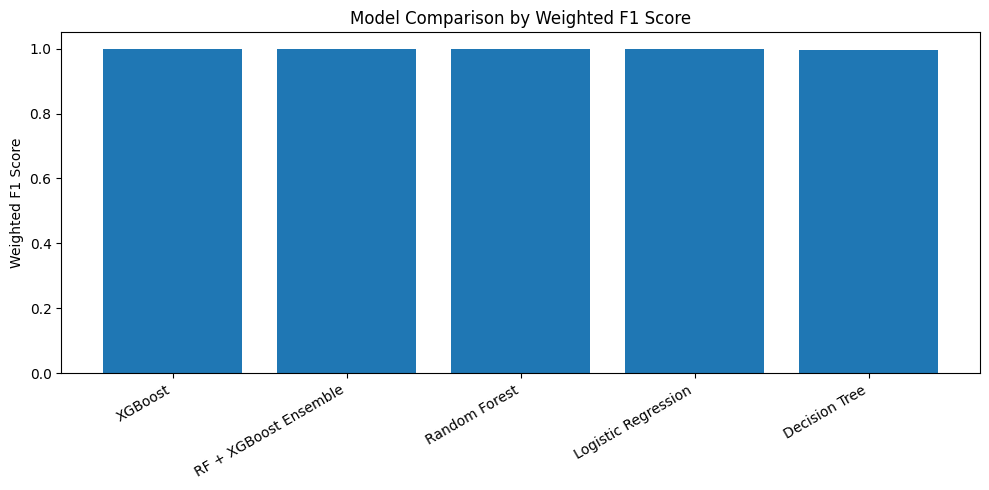

In [9]:
plt.figure(figsize=(10, 5))
plot_df = results_df.sort_values(by="Weighted F1", ascending=False)
plt.bar(plot_df["Model"], plot_df["Weighted F1"])
plt.xticks(rotation=30, ha="right")
plt.ylabel("Weighted F1 Score")
plt.title("Model Comparison by Weighted F1 Score")
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()

## 6. Live Traffic Prediction Function

In [10]:
def predict_live_traffic(sample_dict, model=ensemble_model):
    sample_df = pd.DataFrame([sample_dict])[feature_names]
    pred_class_id = model.predict(sample_df)[0]
    pred_label = label_encoder.inverse_transform([pred_class_id])[0]
    probabilities = model.predict_proba(sample_df)[0]
    benign_id = list(label_encoder.classes_).index("BENIGN")
    attack_probability = 1 - probabilities[benign_id]
    decision = "BENIGN" if pred_label == "BENIGN" else "ATTACK"
    return {
        "decision": decision,
        "predicted_class": pred_label,
        "attack_probability": round(float(attack_probability), 4),
        "confidence": round(float(np.max(probabilities)), 4)
    }

sample = X_test.iloc[0].to_dict()
predict_live_traffic(sample)

{'decision': 'ATTACK',
 'predicted_class': 'DoS',
 'attack_probability': 1.0,
 'confidence': 1.0}

In [11]:
live_dos_sample = {
    "flow_duration": 7500, "total_fwd_packets": 130, "total_bwd_packets": 95,
    "total_length_fwd_packets": 76000, "total_length_bwd_packets": 48000,
    "fwd_packet_length_mean": 584, "bwd_packet_length_mean": 505,
    "flow_bytes_per_sec": 9800, "flow_packets_per_sec": 18,
    "fwd_iat_mean": 58, "bwd_iat_mean": 79,
    "fwd_psh_flags": 4, "bwd_psh_flags": 2,
    "fwd_urg_flags": 1, "bwd_urg_flags": 0,
    "syn_flag_count": 9, "fin_flag_count": 2, "rst_flag_count": 3, "ack_flag_count": 13,
    "packet_length_mean": 551, "average_packet_size": 557
}

predict_live_traffic(live_dos_sample)

{'decision': 'ATTACK',
 'predicted_class': 'DoS',
 'attack_probability': 1.0,
 'confidence': 1.0}

## 7. Save and Load Model using Joblib

In [12]:
artifacts = {
    "model": ensemble_model,
    "label_encoder": label_encoder,
    "feature_names": feature_names
}
joblib.dump(artifacts, "network_intrusion_rf_xgb_ensemble.joblib")
print("Saved: network_intrusion_rf_xgb_ensemble.joblib")

Saved: network_intrusion_rf_xgb_ensemble.joblib


In [13]:
loaded_artifacts = joblib.load("network_intrusion_rf_xgb_ensemble.joblib")
loaded_model = loaded_artifacts["model"]
loaded_label_encoder = loaded_artifacts["label_encoder"]
loaded_features = loaded_artifacts["feature_names"]

sample_df = pd.DataFrame([live_dos_sample])[loaded_features]
pred_id = loaded_model.predict(sample_df)[0]
pred_label = loaded_label_encoder.inverse_transform([pred_id])[0]
print("Loaded model prediction:", pred_label)

Loaded model prediction: DoS
